<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/3_01_NGS_Platforms_and_Sequencing_Chemistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 — High-Throughput Sequencing Platforms & Chemistry Comparison

**Advanced Bioinformatics Lab Session**

## Learning objectives
By the end of this notebook you will be able to:
- Explain the sequencing chemistry of Illumina (SBS), PacBio SMRT, and Oxford Nanopore
- Simulate reads and platform-specific error profiles from a reference sequence
- Quantitatively compare read length distribution, error rate, and error type (substitution vs. indel) across platforms
- Justify platform choice for a given application (SNP calling, structural variant detection, epigenetic profiling)

## Background

| Platform | Chemistry | Read length | Dominant error type | Accuracy |
|---|---|---|---|---|
| Illumina | Sequencing by Synthesis (SBS) | Short (50–300 bp) | Substitution | ~99.9% |
| PacBio SMRT | Real-time, ZMW | Long (10–50 kb+) | Indel (raw), corrected by CCS | Moderate (raw), high (CCS) |
| Oxford Nanopore | Ionic current sensing | Ultra-long (>1 Mb possible) | Indel, homopolymer errors | Improving |

No external data is required — we generate a synthetic reference genome and simulate reads under each platform's error model, so this notebook runs fully offline.

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

np.random.seed(42)
random.seed(42)
sns.set_theme(style="whitegrid", font_scale=1.05)
BASES = ["A", "C", "G", "T"]


## 2. Generate a synthetic reference sequence

We simulate a 20 kb reference (standing in for a gene locus) with realistic local GC-content variation, since GC bias is one of the QC issues we'll revisit in Lab 2.

In [ ]:
def make_reference(length=20000, gc_mean=0.45, gc_drift=0.15, block=500):
    seq = []
    n_blocks = length // block + 1
    for b in range(n_blocks):
        gc = np.clip(np.random.normal(gc_mean, gc_drift), 0.1, 0.9)
        weights = [(1-gc)/2, gc/2, gc/2, (1-gc)/2]  # A C G T
        seq.extend(np.random.choice(BASES, size=block, p=weights))
    return "".join(seq[:length])

reference = make_reference()
print(f"Reference length: {len(reference)} bp")
print(reference[:120], "...")


Reference length: 20000 bp
GGAAATGGATTAAACGCCGACCCTAGGAGAATTTCAGCACATCGCGGATTTTGTAAACCCTCCGATATTAATGGTACATGCACCGGTCAGGGTCGCAAAGCGTCCGAACATTGTTATGTT ...


## 3. Platform-specific read + error simulators

Each function draws a random start position on the reference, extracts a fragment of the platform-typical length, and injects errors according to that platform's dominant error mode and rate.

In [ ]:
def simulate_illumina_read(ref, length=150, sub_rate=0.001):
    start = np.random.randint(0, len(ref) - length)
    frag = list(ref[start:start+length])
    n_errors = 0
    for i in range(len(frag)):
        if np.random.rand() < sub_rate:
            alt = [b for b in BASES if b != frag[i]]
            frag[i] = np.random.choice(alt)
            n_errors += 1
    return "".join(frag), n_errors, "substitution", start, length

def simulate_pacbio_read(ref, length=15000, indel_rate=0.12, ccs_passes=1):
    length = min(length, len(ref) - 1)
    start = np.random.randint(0, len(ref) - length)
    frag = list(ref[start:start+length])
    # raw single-pass error rate ~10-15%, dominated by indels
    out, n_errors = [], 0
    per_pass_rate = indel_rate / ccs_passes  # CCS: more passes -> lower effective error
    for b in frag:
        r = np.random.rand()
        if r < per_pass_rate * 0.6:       # deletion
            n_errors += 1
            continue
        elif r < per_pass_rate:            # insertion before base
            out.append(np.random.choice(BASES))
            n_errors += 1
        out.append(b)
    return "".join(out), n_errors, "indel", start, length

def simulate_nanopore_read(ref, length=30000, indel_rate=0.08, homopolymer_penalty=2.5):
    length = min(length, len(ref) - 1)
    start = np.random.randint(0, len(ref) - length)
    frag = list(ref[start:start+length])
    out, n_errors = [], 0
    i = 0
    while i < len(frag):
        b = frag[i]
        # detect homopolymer run -> higher local error rate
        run = 1
        while i+run < len(frag) and frag[i+run] == b:
            run += 1
        local_rate = indel_rate * (homopolymer_penalty if run >= 3 else 1.0)
        r = np.random.rand()
        if r < local_rate * 0.6:
            n_errors += 1
        elif r < local_rate:
            out.append(np.random.choice(BASES))
            out.append(b)
            n_errors += 1
        else:
            out.append(b)
        i += 1
    return "".join(out), n_errors, "indel", start, length


## 4. Generate a read set per platform

In [ ]:
N_READS = 300

def build_dataset(sim_fn, platform, **kwargs):
    rows = []
    for _ in range(N_READS):
        seq, n_err, err_type, start, length = sim_fn(reference, **kwargs)
        rows.append({
            "platform": platform,
            "read_length": len(seq),
            "n_errors": n_err,
            "error_rate": n_err / max(len(seq), 1),
            "error_type": err_type
        })
    return pd.DataFrame(rows)

illumina_df = build_dataset(simulate_illumina_read, "Illumina (SBS)")
pacbio_df   = build_dataset(simulate_pacbio_read,   "PacBio SMRT (raw)", ccs_passes=1)
pacbio_ccs_df = build_dataset(simulate_pacbio_read, "PacBio SMRT (CCS, 8 passes)", ccs_passes=8)
nanopore_df = build_dataset(simulate_nanopore_read, "Oxford Nanopore")

all_df = pd.concat([illumina_df, pacbio_df, pacbio_ccs_df, nanopore_df], ignore_index=True)
all_df.groupby("platform")[["read_length", "error_rate"]].agg(["mean", "std"]).round(4)


read_length          error_rate        
                                   mean      std       mean     std
platform                                                           
Illumina (SBS)                 150.0000   0.0000     0.0009  0.0025
Oxford Nanopore              19644.6733  42.0084     0.0907  0.0022
PacBio SMRT (CCS, 8 passes)  14954.7467  15.6002     0.0151  0.0009
PacBio SMRT (raw)            14636.8500  42.8526     0.1228  0.0027

## 5. Compare read length distributions

/tmp/ipykernel_546/4140719645.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(sub["read_length"], label=platform, fill=True, alpha=0.25, ax=ax)


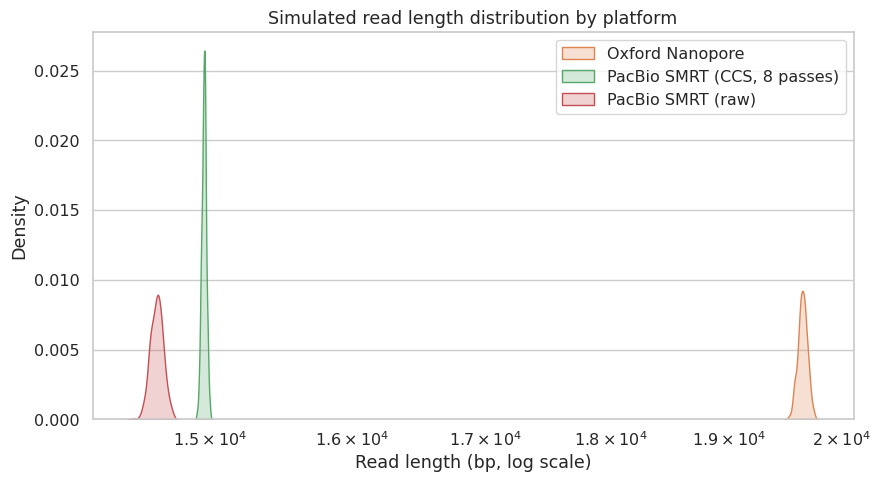

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
for platform, sub in all_df.groupby("platform"):
    sns.kdeplot(sub["read_length"], label=platform, fill=True, alpha=0.25, ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Read length (bp, log scale)")
ax.set_title("Simulated read length distribution by platform")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Compare error rates and error type

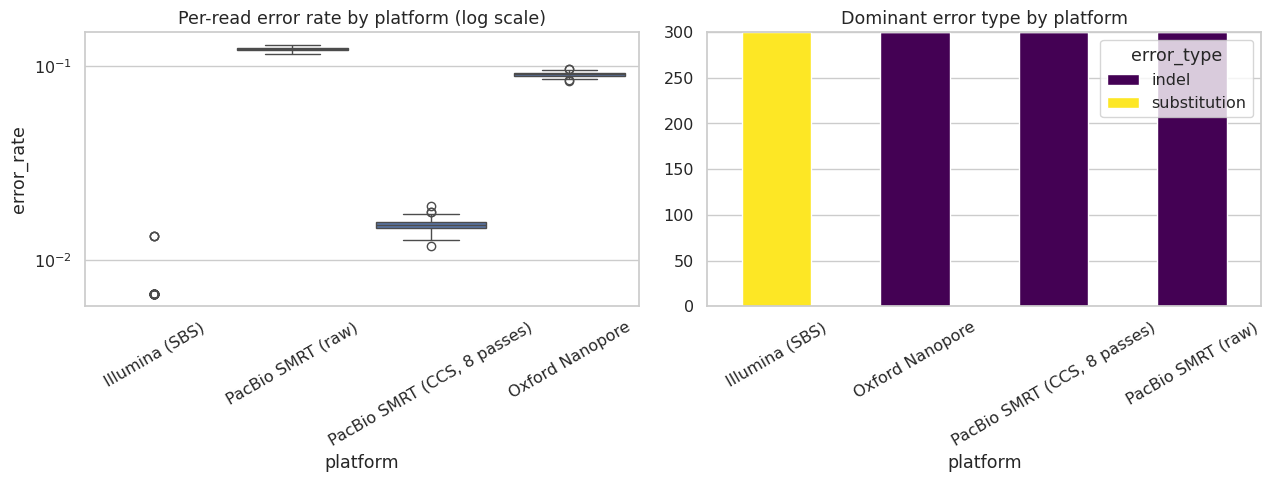

platform
Illumina (SBS)                  0.089%
Oxford Nanopore                 9.074%
PacBio SMRT (CCS, 8 passes)     1.510%
PacBio SMRT (raw)              12.279%
Name: error_rate, dtype: str


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(data=all_df, x="platform", y="error_rate", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Per-read error rate by platform (log scale)")
axes[0].tick_params(axis='x', rotation=30)

err_summary = all_df.groupby(["platform","error_type"]).size().unstack(fill_value=0)
err_summary.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Dominant error type by platform")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(all_df.groupby("platform")["error_rate"].mean().apply(lambda x: f"{x:.3%}"))


## 7. Exercise — Platform selection

For each scenario below, write 2–3 sentences in the markdown cell justifying which platform (Illumina, PacBio SMRT, or Oxford Nanopore) you would choose, referencing the read length / error trade-offs you just quantified above.

1. **Calling somatic SNVs in a tumor sample at high depth** (need highest per-base accuracy, moderate read length is fine)
2. **Resolving a structural variant / large tandem repeat expansion** in a suspected disease locus
3. **Field-deployable pathogen surveillance** requiring real-time results outside a core lab
4. **Detecting 5-methylcytosine (5mC) methylation directly from native DNA**, without bisulfite conversion

*(Your answers here)*

1. ...
2. ...
3. ...
4. ...


In [ ]:
# Optional: quantify the accuracy/read-length trade-off numerically to support your written answers
summary = all_df.groupby("platform").agg(
    mean_length=("read_length","mean"),
    mean_error_rate=("error_rate","mean")
).round(4)
summary["implied_accuracy_%"] = (1 - summary["mean_error_rate"]) * 100
summary.sort_values("mean_length")


,mean_length,mean_error_rate,implied_accuracy_%
platform,,,
Illumina (SBS),150.0000,0.0009,99.91
PacBio SMRT (raw),14636.8500,0.1228,87.72
"PacBio SMRT (CCS, 8 passes)",14954.7467,0.0151,98.49
Oxford Nanopore,19644.6733,0.0907,90.93


## 8. Reflection

- How does PacBio's Circular Consensus Sequencing (CCS) change the effective error rate, and why does the number of passes matter?
- Why does Nanopore's error rate spike in homopolymer regions? What does this imply for variant calling in repetitive genomic regions?
- Which platform's error profile is easiest to correct computationally (i.e. is it random or systematic), and why does that matter for downstream analysis?
